In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

print("Import dataset")
df = pd.read_csv("dataset.csv")
print(df.head())
print(df.tail())
print("Basic Information About Dataset")
df.shape

Import dataset
  Household_ID       City  Household_Size  Monthly_Energy_Consumption_kWh  \
0         H001       Pune               4                             320   
1         H002      Delhi               5                             450   
2         H003  Bangalore               3                             280   
3         H004     Mumbai               6                             500   
4         H005    Chennai               4                             350   

  Renewable_Energy_Used Energy_Source Solar_Panels Electric_Vehicle  \
0                   Yes         Solar          Yes               No   
1                    No          Coal           No               No   
2                   Yes         Solar          Yes              Yes   
3                    No   Natural Gas           No               No   
4                   Yes          Wind           No              Yes   

   Carbon_Emission_Reduction_kg  Environmental_Awareness_Score  
0                            8

(15, 10)

# Dataset Analysis Summary

## 1. General Overview:
This dataset provides information about household energy usage, renewable energy adoption, carbon emission reduction, and environmental awareness levels. Each record represents a household from a different city and shows their energy habits and sustainability practices.

## 2. Relationship Between Features:

- **Household Size and Energy Consumption:**  
  Larger households usually consume more electricity because their daily energy requirements are higher.

- **Renewable Energy and Carbon Reduction:**  
  Households that use renewable energy sources like solar and wind tend to reduce more carbon emissions compared to those using traditional energy sources.

- **Solar Panels and Emissions:**  
  Homes with solar panels generally have better environmental performance and contribute to reducing carbon emissions.

- **Electric Vehicles and Carbon Reduction:**  
  Households with electric vehicles help lower emissions by reducing dependence on fuel-based transportation.

- **Environmental Awareness and Renewable Adoption:**  
  People with higher environmental awareness scores are more likely to use renewable energy and adopt eco-friendly technologies.

## 3. Key Findings:
The analysis shows that renewable energy sources, solar panels, and electric vehicles play an important role in reducing carbon emissions. Households depending on coal and natural gas show lower emission reductions. Overall, higher environmental awareness leads to more sustainable energy choices.

Null values:
Household_ID                      0
City                              0
Household_Size                    0
Monthly_Energy_Consumption_kWh    0
Renewable_Energy_Used             0
Energy_Source                     0
Solar_Panels                      0
Electric_Vehicle                  0
Carbon_Emission_Reduction_kg      0
Environmental_Awareness_Score     0
dtype: int64
Null values after handling:
Household_ID                      0
City                              0
Household_Size                    0
Monthly_Energy_Consumption_kWh    0
Renewable_Energy_Used             0
Energy_Source                     0
Solar_Panels                      0
Electric_Vehicle                  0
Carbon_Emission_Reduction_kg      0
Environmental_Awareness_Score     0
dtype: int64
  Household_ID       City  Household_Size  Monthly_Energy_Consumption_kWh  \
0         H001       Pune               4                             320   
1         H002      Delhi               5                  

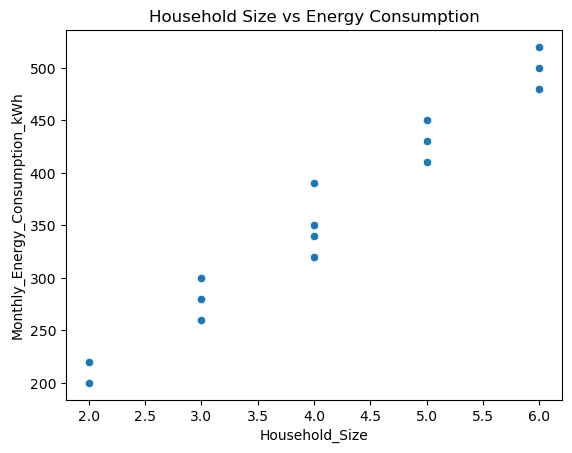

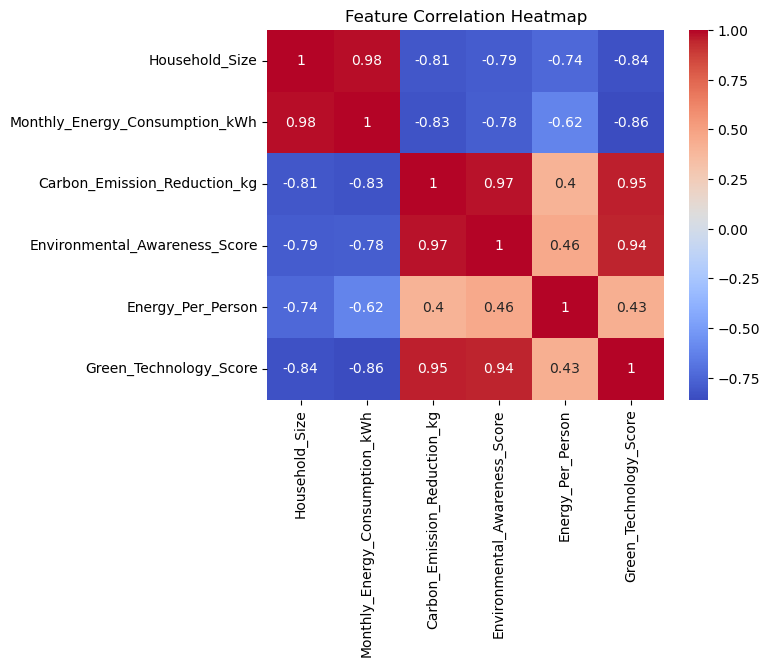

Final Dataset:
  Household_ID  Household_Size  Monthly_Energy_Consumption_kWh  \
0         H001       -0.101797                       -0.443606   
1         H002        0.661683                        0.887212   
2         H003       -0.865277                       -0.853088   
3         H004        1.425162                        1.399065   
4         H005       -0.101797                       -0.136494   

   Renewable_Energy_Used  Solar_Panels  Electric_Vehicle  \
0                      1             1                 0   
1                      0             0                 0   
2                      1             1                 1   
3                      0             0                 0   
4                      1             0                 1   

   Carbon_Emission_Reduction_kg  Environmental_Awareness_Score  \
0                      0.212393                       0.291959   
1                     -1.299161                      -1.104367   
2                      1.0263

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
df = pd.read_csv("dataset.csv")
print("Null values:")
print(df.isnull().sum())
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("Null values after handling:")
print(df.isnull().sum())
df["Energy_Per_Person"] = (
    df["Monthly_Energy_Consumption_kWh"] / df["Household_Size"]
)
df["Green_Technology_Score"] = (
    df["Renewable_Energy_Used"].map({"Yes":1, "No":0}) +
    df["Solar_Panels"].map({"Yes":1, "No":0}) +
    df["Electric_Vehicle"].map({"Yes":1, "No":0})
)

print(df.head())
sns.scatterplot(
    data=df,
    x="Household_Size",
    y="Monthly_Energy_Consumption_kWh"
)
plt.title("Household Size vs Energy Consumption")
plt.show()

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()
encoder = LabelEncoder()

c1 = ["Renewable_Energy_Used","Solar_Panels", "Electric_Vehicle"]

for col in c1:
    df[col] = encoder.fit_transform(df[col])
df = pd.get_dummies(
    df,
    columns=["Energy_Source", "City"],
    drop_first=True
)
scaler = StandardScaler()
n1 = ["Household_Size","Monthly_Energy_Consumption_kWh",
    "Carbon_Emission_Reduction_kg",
    "Environmental_Awareness_Score",
    "Energy_Per_Person",
    "Green_Technology_Score"]
df[n1] = scaler.fit_transform( df[n1])
print("Final Dataset:")
print(df.head())

# Insights and Reasoning

- The dataset had no missing values, so no changes were needed. A general null-handling method was added to manage future missing data.
- Created **Energy_Per_Person** to compare energy usage between households of different sizes.
- Created **Green_Technology_Score** to measure how environmentally friendly a household is based on renewable energy, solar panels, and EV usage.
- Converted categorical values into numbers because machine learning models cannot directly process text data.
- Used one-hot encoding for City and Energy Source because these categories do not have any ranking.
- Applied scaling to numerical features so that all values are on a similar range and no feature dominates others.
- Visualizations helped understand patterns like higher renewable energy usage leading to better carbon reduction and larger households consuming more energy.
Overall, the analysis shows that renewable energy, solar panels, and electric vehicles play an important role in reducing carbon emissions.